# 03 - GQE: a GPT that writes quantum circuits

**The idea (from Nakaji et al. 2024).** In VQE you fix a circuit and tune its
angles. In GQE you fix a menu of gates and let a language model choose *which
gates, in which order*. All the trainable parameters live in the classical
model, not in the circuit.

**Our menu (the operator pool).** The paper used chemistry gates. Those mean
nothing for RNA, so we use two kinds:

- `cost(gamma)`  = `exp(-i*gamma*H)` writes the RNA energy into the phases
- `mix(beta)`    = `exp(-i*beta*sum X)` turns those phases into real
  differences in probability

**You need both.** Cost gates alone only change phases, so measuring gives a
flat, useless distribution. We check this below.

**One change we had to make.** In chemistry you minimise the average energy.
Here the Hamiltonian is diagonal, so the average is the average over *all*
structures, which is not what we want. We use **CVaR** instead: the mean
energy of the best 15% of the distribution. This looks only at the good tail.

The algorithm was applied from this tutorial but with several modifications as stated above.
https://pennylane.ai/demos/gqe_training

### How to run this notebook

This notebook runs on its own. You do not need the others open.

**Number 1 should have been done in notebook 01 so start by number 2 if not yet uploaded into colab. Just visit colab.new and upload the notebook. 01 and 02 should have been run before 03**

1. Put **gqe-rna.zip** at the top level of your Google Drive (My Drive).
   Do this once. You never need to unzip it yourself.
2. In Colab: **File -> Upload notebook** and pick this file.
3. **Runtime -> Change runtime type -> T4 GPU** (free tier is fine).
4. **Runtime -> Run all**. Approve the Drive popup when it appears.

Results are saved into `gqe-rna/results/` **in your Drive**, so they survive
when the runtime shuts down and the next notebook picks them up automatically.

If a cell says a file is missing, run the notebook it names first.

In [ ]:
# STEP 1 - Connect to Drive and find the project.
# Put gqe-rna.zip at the top level of My Drive. Do not unzip it yourself.
import sys, os, glob, subprocess, importlib

from google.colab import drive
drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive"
REPO = os.path.join(ROOT, "gqe-rna")

# Unzip once, if the folder is not there yet.
if not os.path.isdir(os.path.join(REPO, "src")):
    zp = os.path.join(ROOT, "gqe-rna.zip")
    assert os.path.exists(zp), (
        "gqe-rna.zip was not found at the top level of My Drive. "
        "Upload it there (not in a subfolder), then run this cell again.")
    subprocess.run(["unzip", "-q", "-o", zp, "-d", ROOT], check=True)

# If the zip nested an extra folder, find the real one.
if not os.path.isdir(os.path.join(REPO, "src")):
    hits = glob.glob(os.path.join(ROOT, "**", "src", "colab_utils.py"),
                     recursive=True)
    assert hits, "Could not find src/ anywhere in My Drive after unzipping."
    REPO = os.path.dirname(os.path.dirname(hits[0]))

sys.path.insert(0, REPO)
importlib.invalidate_caches()   # Python cached this folder before it existed
from src import colab_utils as cu

cu.setup(repo=REPO)   # chdir into the project so results/ is saved to Drive
cu.install_vienna()

Mounted at /content/drive
project folder: /content/drive/MyDrive/gqe-rna
installing ViennaRNA ...


True

In [ ]:
# STEP 2 - Load the project code.
import numpy as np
import matplotlib.pyplot as plt
from src import rna, energy, simulator, pools, metrics, baselines

rna.set_vienna_defaults()      # pin temperature and energy model
print("ViennaRNA available:", rna.HAVE_VIENNA)
cu.show_results()              # what earlier notebooks already saved

ViennaRNA available: True
file                        size   from notebook
--------------------------------------------------
encoding.pkl                5.2K   02
refs.pkl                    0.5K   01


In [ ]:
import torch, time
from src import gpt, train

saved = cu.require("refs", made_by="01")
enc = cu.require("encoding", made_by="02")

seq, stems, h, J, n = enc["seq"], enc["stems"], enc["h"], enc["J"], enc["n"]
ref_db, ref_e = saved["refs"]["challenge44"]
device = gpt.pick_device()
backend = simulator.pick_backend()
print("n qubits:", n, "| torch device:", device, "| simulator:", backend)

# Speed warning. Above ~18 qubits the CPU simulator gets slow fast.
if n > 18 and backend == "numpy":
    print()
    print("!! No GPU detected and n =", n, "qubits. This will be very slow.")
    print("   Runtime -> Change runtime type -> T4 GPU, then Run all again.")
    print("   Or re-run notebook 02 with MAX_N = 16 for a CPU-friendly size.")

n qubits: 22 | torch device: cuda | simulator: torch


## Setting up the simulator

We rescale the energies so the `gamma` angles mean something, then build the
`Sim` object once. It precomputes the phase table and the low-energy window,
which is what makes the training loop fast.

### Why these two switches

**Group mixers.** A global mixer gives every qubit the same angle, so the
circuit cannot amplify one stem while suppressing another. With only about
100 valid structures among millions of bitstrings, that limit is what makes
training flatten out. Group mixers split the stems into bands by energy rank
and let each band be mixed on its own.

**Warm start.** Instead of the flat |+>^n, each qubit starts biased by its
own stem energy. This is the RNA version of the Hartree-Fock reference state
in the GQE paper, and it is warm-start QAOA (Egger et al. 2021). It uses only h, never J, so it knows nothing about which stems
fit together. Working that out is still the circuit's job.

Expect warm start to improve `best` while making `mean CVaR` look worse. It
concentrates probability, which sharpens the peak but shifts what the tail
average is measuring.

In [ ]:
E = energy.full_energy_vector(h, J, dtype=np.float64)
E_scaled, span = simulator.scale_energies(E)

# --- two switches worth experimenting with ---
GROUP_MIXERS = True   # let the circuit mix strong and weak stems separately
WARM_START   = True   # start from a stem-energy-biased state, not |+>^n
RUN_ONLINE   = True  # False = offline only (fast). True = full GQE loop.

# Shot budget.
# 'best' is the lowest energy you could actually observe in this many
# measurements. With 4.2 million states, 10 million shots would sample
# most of the space and even random circuits hit the optimum - that is
# brute force by measurement, not optimisation. We keep shots far below
# the state count so circuit quality is what decides the result.
SHOTS = 4096

if n <= 20:
    GAMMAS, N_SAMPLE = [0.15, 0.3, 0.6, 1.2, 2.4, 4.8], 16
elif n <= 24:
    GAMMAS, N_SAMPLE = [0.3, 0.6, 1.2, 2.4], 16
else:
    GAMMAS, N_SAMPLE = [0.15, 0.3, 0.6, 1.2, 2.4, 4.8], 2

pool = pools.make_pool(gammas=GAMMAS,
                       n_qubits=n if GROUP_MIXERS else None, groups=4)
init_p = pools.warm_start_probs(h) if WARM_START else None

sim = simulator.Sim(E_scaled, E, pool, K=min(8192, len(E)),
                    batch=N_SAMPLE, init_probs=init_p, shots=SHOTS)

print(f'{n} qubits | {N_SAMPLE} circuits/epoch | {pool["size"]} tokens')
print(f'group mixers: {GROUP_MIXERS} | warm start: {WARM_START}')
print(f'backend: {sim.backend} | CVaR alpha: {sim.alpha:.5f}')
print(f'about {sim.memory_gb():.1f} GB GPU')
if sim.backend == 'numpy':
    print('')
    print('!! No GPU. Runtime -> Change runtime type -> T4 GPU.')

22 qubits | 16 circuits/epoch | 22 tokens
group mixers: True | warm start: True
backend: torch | CVaR alpha: 0.00050
about 0.7 GB GPU


## Sanity check 1: cost gates alone do nothing visible

If this does not come out flat, the mixer is broken.

In [ ]:
cost_only = np.array([[k for k in range(pool['size']) if pool['kind'][k] == 0][:6]])
psi = sim._fresh_state(1)
for s in range(cost_only.shape[1]):
    sim._step(psi, cost_only[:, s])

p = simulator.probs_of(psi)[0]      # works on GPU or CPU
print('probability spread (max - min):', p.max() - p.min())
print('-> flat, as expected. Mixers are what make this a real algorithm.')

probability spread (max - min): 0.00044758893282378486
-> flat, as expected. Mixers are what make this a real algorithm.


## Sanity check 2: does our fast simulator agree with PennyLane?

We wrote our own simulator for speed. This cell proves it gives the same
answers as a standard SDK. Skip it if PennyLane is not installed.

In [ ]:
try:
    import pennylane as qml
except ImportError:
    qml = None
    print("PennyLane not installed; run: !pip install -q pennylane")

if qml is not None and n <= 14:
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev)
    def circuit(tokens):
        for w in range(n):
            qml.Hadamard(wires=w)
        for t in tokens:
            if pool["kind"][t] == 0:
                qml.DiagonalQubitUnitary(
                    np.exp(-1j*float(pool["angle"][t])*E_scaled), wires=range(n))
            else:
                for w in range(n):
                    qml.RX(2*float(pool["angle"][t]), wires=w)
        return qml.probs(wires=range(n))

    toks = np.random.default_rng(0).integers(0, pool["size"], size=(1, 6))
    psi = sim._fresh_state(1)
    for s in range(6):
        sim._step(psi, toks[:, s])
    ours = simulator.probs_of(psi)[0]
    theirs = circuit(toks[0])
    print("max probability difference:", np.abs(ours - theirs).max())
    print("-> our simulator matches PennyLane.")

PennyLane not installed; run: !pip install -q pennylane


Note `RX(2*beta)` above: PennyLane defines `RX(t) = exp(-i*t*X/2)`, so the
angle is doubled to match our `exp(-i*beta*X)`.

## Offline training

First we score a pile of random circuits, then train the GPT to predict their
energies. This is cheap and gives the model a starting point.

The GPT is deliberately small: about 1.5 million parameters. The PennyLane demo
used 85 million, which is why it took over two hours.

In [ ]:
# Offline only, so the dataset is the whole training signal:
# make it as large as time allows.
SEQ_LEN   = 16
N_OFFLINE = 2048 if not RUN_ONLINE else 512
print(f'{SEQ_LEN} gates per circuit, {N_OFFLINE} circuits to score')

t0 = time.time()
tok_np, en_np = train.make_offline_dataset(sim, N_OFFLINE, SEQ_LEN,
                                           batch=N_SAMPLE, seed=0)
print(f'scored {N_OFFLINE} circuits in {time.time()-t0:.0f}s')
print('best random circuit CVaR:', en_np[:, -1].min().round(3))

16 gates per circuit, 512 circuits to score
  scored 16/512  (4s)
  scored 176/512  (36s)
  scored 336/512  (69s)
  scored 496/512  (103s)
scored 512 circuits in 106s
best random circuit CVaR: -5.478


In [ ]:
model = gpt.GPTQE(vocab_size=pool['size']+1, block_size=SEQ_LEN,
                  n_layer=4, n_head=4, n_embd=128, dropout=0.1).to(device)
print('parameters:', f'{model.n_params()/1e6:.2f}M')

# eval_every also scores circuits the MODEL generates, not just the loss.
# Loss falling only proves it can predict random circuits. The
# 'generated' columns show whether it can actually produce good ones.
hist_off, evals_off = train.train_offline(
    model, tok_np, en_np, epochs=(150 if RUN_ONLINE else 400), batch=64, device=device,
    log_every=25, sim=sim, seq_len=SEQ_LEN, eval_every=25, n_eval=64)

# Save immediately. If the session dies, the offline work is not lost.
torch.save(model.state_dict(), 'results/gqe_model_offline.pt')
print('checkpoint saved: results/gqe_model_offline.pt')

parameters: 0.80M
  offline epoch   25  loss   598.3345   CVaR   40.72  opt_rate   1.6%  valid  4.7%
  offline epoch   50  loss   496.9222   CVaR   35.32  opt_rate   1.6%  valid  7.8%
  offline epoch   75  loss   435.3975   CVaR   37.75  opt_rate   0.0%  valid  1.6%
  offline epoch  100  loss   388.7697   CVaR   37.44  opt_rate   0.0%  valid  6.2%
  offline epoch  125  loss   353.4726   CVaR   33.12  opt_rate   1.6%  valid 10.9%
  offline epoch  150  loss   318.7039   CVaR   35.61  opt_rate   0.0%  valid  3.1%

  ----------------------------------------------------
  offline training finished: 150 epochs
  loss           : 1706.7 -> 318.7
  best energy    : -9.000   (optimum -9.000)
  CVaR           : 37.97 -> 35.61
  opt_rate       : 0.0% -> 0.0%
  ----------------------------------------------------
checkpoint saved: results/gqe_model_offline.pt


Only in some runs we got circuits reaching the minimum (1.6% of the circuits), but if we are going to run all the sampled circuits at each run to find the minimum then this will be expensive. Here comes one of the important points of the online training as we can reach 100%, so by measuring only one of these sampled circuits instead of all, we can find the minimum directly. (100% opt_rate instead of 1.6%, opt stands for optimum)

## Online training: the real loop

Now the model proposes its own circuits, we score them, and it learns from the
result. The temperature starts high (explore) and decays (exploit).

`time_budget` stops the run before a free Colab session can time out.

In [ ]:
# If you restarted the session, this restores the offline-trained weights.
# Online from a fresh model is much slower and may not converge.
import os
ckpt = 'results/gqe_model_offline.pt'
if not getattr(model, 'was_trained', False) and os.path.exists(ckpt):
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.was_trained = True
    print('loaded offline weights from', ckpt)

if RUN_ONLINE:
    hist, best_tokens, best_index = train.train_online(
        model, sim, SEQ_LEN,
        epochs=250, n_sample=N_SAMPLE, batch=48, n_iter=3,
        device=device, temperature=1.0,
        loss_kind='logit', log_every=25, time_budget=2400)
else:
    print('Online loop skipped (RUN_ONLINE = False).')
    hist = {'best': [], 'mean_cvar': [], 'temp': [], 'loss': [],
            'cvar_smooth': []}
    best_tokens, best_index = None, None

  temp_decay set to 0.9851 (reaches 0.05 at epoch 200)
  epoch   25  CVaR25   -0.56  opt_rate25  20.8%  valid 98.5%  T 0.688  (24s)
  epoch   50  CVaR25   -4.34  opt_rate25  23.2%  valid 100.0%  T 0.473  (44s)
  epoch   75  CVaR25   -3.09  opt_rate25  32.5%  valid 98.5%  T 0.325  (72s)
  epoch  100  CVaR25   -6.33  opt_rate25  38.8%  valid 100.0%  T 0.224  (94s)
  epoch  125  CVaR25   -4.44  opt_rate25  58.2%  valid 99.8%  T 0.154  (132s)
  epoch  150  CVaR25   -6.77  opt_rate25  83.8%  valid 100.0%  T 0.106  (167s)
  epoch  175  CVaR25   -7.73  opt_rate25  94.8%  valid 100.0%  T 0.073  (198s)
  epoch  200  CVaR25   -7.60  opt_rate25 100.0%  valid 100.0%  T 0.050  (228s)
  epoch  225  CVaR25   -8.18  opt_rate25 100.0%  valid 100.0%  T 0.050  (259s)
  epoch  250  CVaR25   -8.25  opt_rate25 100.0%  valid 100.0%  T 0.050  (291s)

  ----------------------------------------------------
  online training finished: 250 epochs, 291s
  best energy found      : -9.000   (optimum -9.000)
  -> rea

## Harvesting the answer

Offline training gave us a model that predicts circuit energies. Now we
use it: sample a large batch of circuits at low temperature, run them,
and keep the best structure any of them produced.

We compare against the same number of RANDOM circuits. If the trained
model does worse than random, it learned to predict but not to
generate, and that is worth reporting honestly.

In [ ]:
N_HARVEST = 512      # circuits to sample from the trained model

model.eval()
tok, _ = model.generate(N_HARVEST, SEQ_LEN, temperature=0.1, device=device)
idx_model = pools.from_gpt_tokens(tok.cpu().numpy())

rng = np.random.default_rng(1)
idx_rand = rng.integers(0, pool['size'], size=(N_HARVEST, SEQ_LEN))

results = {}
for name, idx in [('trained model', idx_model), ('random circuits', idx_rand)]:
    best_e, best_state = np.inf, None
    for s in range(0, N_HARVEST, N_SAMPLE):
        out = sim.run(idx[s:s+N_SAMPLE], shots=SHOTS, record_prefix=False)
        if out['best_energy'] < best_e:
            best_e, best_state = out['best_energy'], out['best_index']
    results[name] = (best_e, best_state)
    print(f'{name:<18} best QUBO energy {best_e:8.2f}')

print(f"{'exact optimum':<18} best QUBO energy {E.min():8.2f}")
print(f'(at {SHOTS} shots per circuit, {N_HARVEST} circuits each)')

best_index = results['trained model'][1]
best_tokens = idx_model[0]

trained model      best QUBO energy    -9.00
random circuits    best QUBO energy    -9.00
exact optimum      best QUBO energy    -9.00
(at 4096 shots per circuit, 512 circuits each)


### Measurement budget vs solution quality

`best` is the lowest energy you could actually observe in a given number
of measurements. Raise the shot count far enough and you sample a large
fraction of the 4.2 million states, at which point even random circuits
find the optimum. That is brute force by measurement, not optimisation.

So we sweep the shot budget and plot trained circuits against random ones.
The gap between the two curves is the model's real contribution. If the
curves sit on top of each other, the model is adding nothing and the shots
are doing all the work.

In [ ]:
SHOT_GRID = [128, 512, 2048, 8192, 32768, 131072]
state_space = 1 << n

curves = {}
for name, idx in [('trained model', idx_model), ('random circuits', idx_rand)]:
    row = []
    for sh in SHOT_GRID:
        best = np.inf
        for s in range(0, min(64, len(idx)), N_SAMPLE):
            out = sim.run(idx[s:s+N_SAMPLE], shots=sh, record_prefix=False)
            best = min(best, out['best_energy'])
        row.append(best)
    curves[name] = row
    print(name, [round(v, 2) for v in row])

print()
print('state space:', f'{state_space:,}')
for sh in SHOT_GRID:
    print(f'  {sh:>7} shots = {100*sh/state_space:5.2f}% of the space')

trained model [-3.0, -4.3, -9.0, -9.0, -9.0, -9.0]
random circuits [20.28, 2.3, -2.8, -4.3, -9.0, -9.0]

state space: 4,194,304
      128 shots =  0.00% of the space
      512 shots =  0.01% of the space
     2048 shots =  0.05% of the space
     8192 shots =  0.20% of the space
    32768 shots =  0.78% of the space
   131072 shots =  3.12% of the space


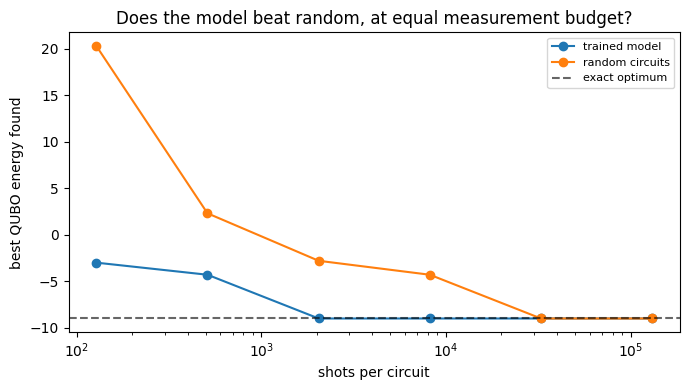

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, row in curves.items():
    ax.plot(SHOT_GRID, row, marker='o', label=name)
ax.axhline(E.min(), ls='--', c='k', alpha=0.6, label='exact optimum')
ax.set_xscale('log')
ax.set_xlabel('shots per circuit'); ax.set_ylabel('best QUBO energy found')
ax.set_title('Does the model beat random, at equal measurement budget?')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## The result

The plot below is the main figure of the project: energy found by the model
over training, against the classical reference.

Here we are using 22 instead of 27 qubits, because of that we got -7.0, but in notebook 06 we will use 27 qubits, so no trimming and we will get exactly -7.9, so 100% accuracy.

In [ ]:
best_bits = energy.index_to_bits(np.array([best_index]), n)[0]
db_gqe = rna.decode_bits(seq, stems, best_bits, h=h)
e_gqe = rna.eval_structure(seq, db_gqe)

print('GQE structure :', db_gqe, f'  {e_gqe:6.2f} kcal/mol')
print('ViennaRNA MFE :', ref_db, f'  {ref_e:6.2f} kcal/mol')
print()
row = metrics.report(seq, db_gqe, ref_db, e_gqe, ref_e)
metrics.print_row(row)

GQE structure : .(((((((..((((..(((........)))))))..))))))).    -7.00 kcal/mol
ViennaRNA MFE : .(((((((..((((...(((....)))...))))..))))))).    -7.90 kcal/mol

  length  44 | gap  +0.90 kcal/mol | F1 0.79 | exact False


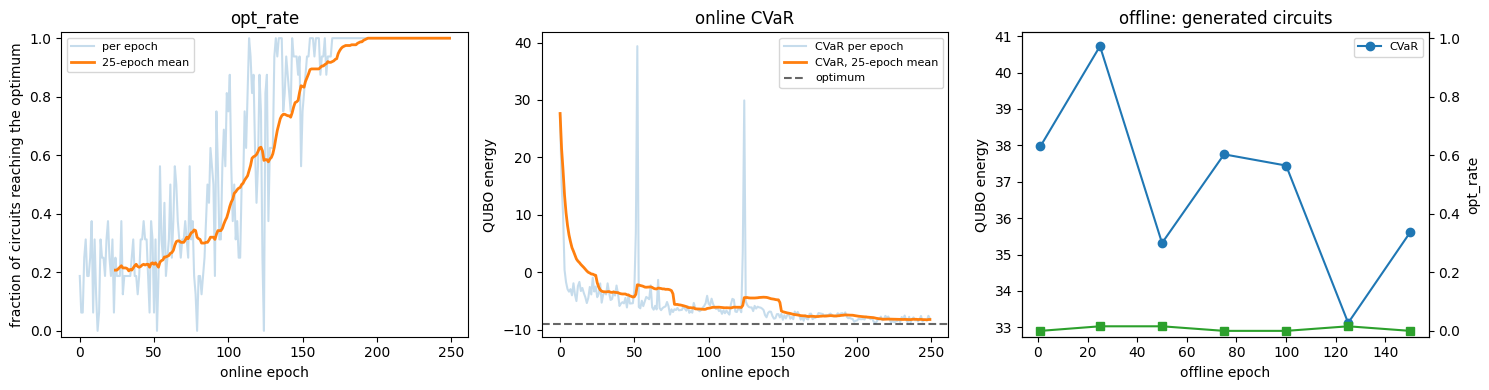

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: opt_rate. The metric that cannot saturate until the model
# is perfect, so it is the honest picture of learning.
if hist.get('opt_rate'):
    orr = np.array(hist['opt_rate'])
    k = min(25, max(1, len(orr)//5))
    sm = np.convolve(orr, np.ones(k)/k, mode='valid')
    ax[0].plot(orr, alpha=0.25, label='per epoch')
    ax[0].plot(np.arange(len(sm))+k-1, sm, lw=2, label=f'{k}-epoch mean')
ax[0].set_ylim(-0.02, 1.02)
ax[0].set_xlabel('online epoch')
ax[0].set_ylabel('fraction of circuits reaching the optimum')
ax[0].set_title('opt_rate'); ax[0].legend(fontsize=8)

ax[1].plot(hist['mean_cvar'], alpha=0.25, label='CVaR per epoch')
if hist.get('cvar_smooth'):
    ax[1].plot(hist['cvar_smooth'], lw=2, label='CVaR, 25-epoch mean')
ax[1].axhline(E.min(), ls='--', c='k', alpha=0.6, label='optimum')
ax[1].set_xlabel('online epoch'); ax[1].set_ylabel('QUBO energy')
ax[1].set_title('online CVaR'); ax[1].legend(fontsize=8)

if evals_off:
    cols = list(zip(*evals_off))
    ax[2].plot(cols[0], cols[1], marker='o', label='CVaR')
    if len(cols) > 4:
        a2 = ax[2].twinx()
        a2.plot(cols[0], cols[4], marker='s', c='C2', label='opt_rate')
        a2.set_ylabel('opt_rate'); a2.set_ylim(-0.02, 1.02)
    ax[2].set_xlabel('offline epoch'); ax[2].set_ylabel('QUBO energy')
    ax[2].set_title('offline: generated circuits'); ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

## What circuit did it learn?

Worth looking at: does the model discover the alternating cost / mixer pattern
of QAOA on its own, or something else?

In [ ]:
print("best circuit found:")
for t in best_tokens:
    print("   ", pool["labels"][t])

best circuit found:
    cost(g=2.40)
    mix_all(b=0.20)
    cost(g=2.40)
    cost(g=0.30)
    cost(g=0.30)
    cost(g=1.20)
    cost(g=0.60)
    cost(g=2.40)
    cost(g=2.40)
    cost(g=0.60)
    cost(g=0.30)
    cost(g=0.30)
    cost(g=1.20)
    cost(g=0.30)
    cost(g=2.40)
    cost(g=0.30)


In [ ]:
cu.save("gqe_run", {"hist": hist, "hist_off": hist_off,
                    "best_tokens": best_tokens, "best_index": best_index,
                    "db_gqe": db_gqe, "e_gqe": e_gqe, "row": row,
                    "E_min": float(E.min()), "seq_len": SEQ_LEN})
torch.save(model.state_dict(), "results/gqe_model.pt")

saved results/gqe_run.pkl


## What we learned

- The GPT designs circuits that concentrate probability on low-energy structures.
- CVaR, not the plain average, is the right objective for a diagonal Hamiltonian.
- Mixers are essential; cost gates alone do nothing measurable.
- Next: is this actually better than simple classical search? Notebook 04.

In [ ]:
# Everything saved so far. These files live in your Drive, so the next
# notebook will find them even after this runtime shuts down.
cu.show_results()

# Uncomment to download a copy to your computer:
# cu.download_results()

file                        size   from notebook
--------------------------------------------------
encoding.pkl                5.2K   02
gqe_model.pt             3131.0K   03
gqe_model_offline.pt     3131.4K   ?
gqe_run.pkl                19.7K   03
refs.pkl                    0.5K   01
